In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.multitest as multi

In [3]:
import matplotlib as mpl
import matplotlib.cm as cm
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [4]:
def ldhub(sumstats,mp_rsid):
    summary=pd.read_csv(sumstats,delimiter="\t")
    summary["variant"]=summary["ID"].str.rsplit(":",2).str[0]
    summary["rsid"]=summary["variant"].map(mp_rsid)
    summary_rsid=summary[~(summary["rsid"].isnull())]
    summary_rsid["BETA"]=np.where(summary_rsid["A1"]!=summary_rsid["ALT"],summary_rsid["BETA"]*-1,summary_rsid["BETA"])
    summary_rsid["Zscore"]=summary_rsid["BETA"]/summary_rsid["SE"]
    summary_rsid=summary_rsid.rename(columns={"OBS_CT":"N","ALT":"A1","REF":"A2","P":"P-value","rsid":"snpid"})
    return(summary_rsid)

In [5]:
def fdr(df,p):
    #calculate benjamin-hochberg fdr
    probabilities = df[p].to_numpy()
    report = multi.multipletests(probabilities,
                alpha=0.05,
                method="fdr_bh",
                is_sorted=False,
            )
    discoveries = report[1]
    df["fdr"]=discoveries
    df["fdr"]=pd.to_numeric(df["fdr"])
    df["-log10(fdr)"]=-np.log10(df["fdr"])
    return(df)

## Prepare LDHub Input

In [9]:
# dbsnp=pd.read_csv("/cellar/users/mpagadal/resources/rsid/hg19_avsnp147.txt",delimiter="\t",header=None)
# mhc=pd.read_csv("../data/ldhub/w_hm3.noMHC.snplist",delimiter="\t")
# dbsnp_filt=dbsnp[dbsnp[5].isin(mhc["SNP"].tolist())]
# dbsnp_filt["variant"]=dbsnp_filt[0].astype(str)+":"+dbsnp_filt[1].astype(str)
# mp_rsid=dict(zip(dbsnp_filt["variant"],dbsnp_filt[5]))

In [10]:
# eur=ldhub("../data/summarystats/full/compiled.eur.release4.testosterone.glm.linear",mp_rsid)
# eur[["snpid","A1","A2","Zscore","N","P-value"]].to_csv("../data/ldhub/ldhub.mvp.his.txt",index=None,sep="\t")

In [11]:
# afr=ldhub("../data/summarystats/full/compiled.afr.release4.testosterone.glm.linear",mp_rsid)
# afr[["snpid","A1","A2","Zscore","N","P-value"]].to_csv("../data/ldhub/ldhub.mvp.afr.txt",index=None,sep="\t")

In [12]:
# his=ldhub("../data/summarystats/full/compiled.his.release4.testosterone.glm.linear",mp_rsid)
# his[["snpid","A1","A2","Zscore","N","P-value"]].to_csv("../data/ldhub/ldhub.mvp.his.txt",index=None,sep="\t")

## Obtain LDHub Output

/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # This is added back by InteractiveShellApp.init_path()
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyW

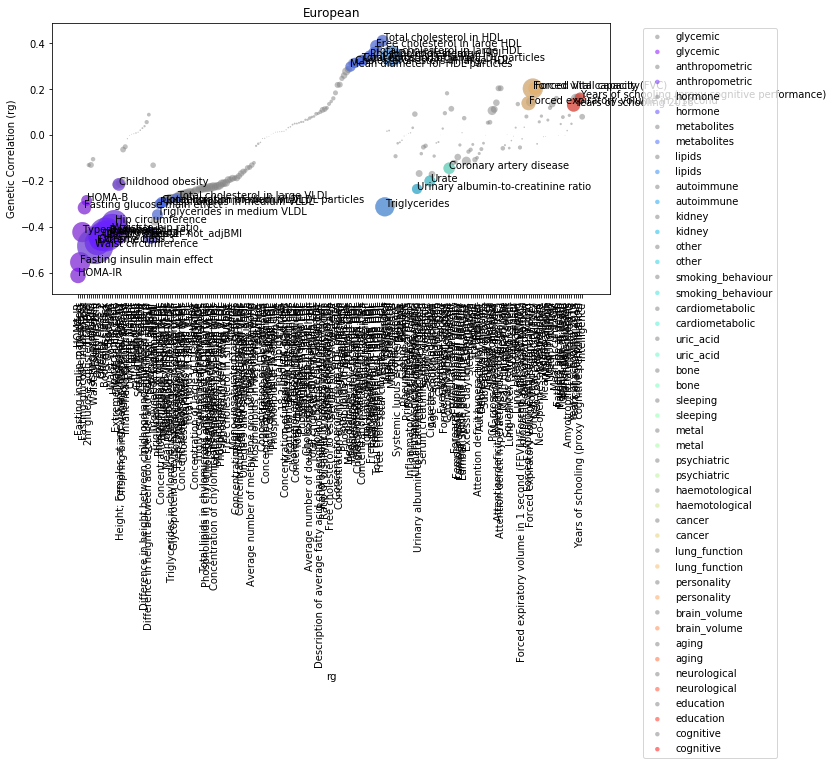

In [13]:
eur=pd.read_csv("../data/ldhub/ldhub.mvp.eur.txt.857adeaf-4a10-44ce-ba54-d7e04916e12f.rg.results.csv")
afr=pd.read_csv("../data/ldhub/ldhub.mvp.afr.txt.7c43e30f-cba2-4e37-8264-a037b85152fc.rg.results.csv")
his=pd.read_csv("../data/ldhub/ldhub.mvp.his.txt.c1342923-96f4-403d-ae31-04b7a87db00c.rg.results.csv")

eur=fdr(eur[~eur["p"].isnull()],"p")
eur=eur[eur["Category"]!="ukbb"]
eur=eur[eur["Category"]!="reproductive"]

#scale size
eur["size"]=eur["-log10(fdr)"]*50

#sort values by genetic correlation and remove duplicates
eur=eur.sort_values("rg",ascending=False).drop_duplicates("trait2").sort_index()

f=plt.figure(figsize=(10,5))
eur=eur.sort_values(by="rg")

colors = iter(cm.rainbow(np.linspace(0, 1, len(eur["Category"].unique()))))

for x in eur["Category"].unique():
    #plot nonsignificant results
    plt.scatter(eur[eur["Category"]==x]["trait2"],eur[eur["Category"]==x]["rg"],s=eur[eur["Category"]==x]["size"],label=x,color="gray",alpha=0.5, edgecolors='none')

    #plot significant results
    eur_sig=eur[eur["fdr"]<.01]
    plt.scatter(eur_sig[eur_sig["Category"]==x]["trait2"],eur_sig[eur_sig["Category"]==x]["rg"],s=eur_sig[eur_sig["Category"]==x]["size"],label=x,alpha=0.5, color=next(colors), edgecolors='none')
    for i,row in eur_sig[eur_sig["Category"]==x].iterrows():
        plt.text(row["trait2"],float(row["rg"]),row["trait2"],color="black")

plt.xlabel("rg")
plt.xticks(rotation=90)
plt.ylabel("Genetic Correlation (rg)")
plt.title("European")

#make legend plot points same size
lgnd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',  fontsize=10)
for handle in lgnd.legendHandles:
    handle.set_sizes([20.0])
plt.savefig("../plots/ldhub/eur.ldhub.pdf")


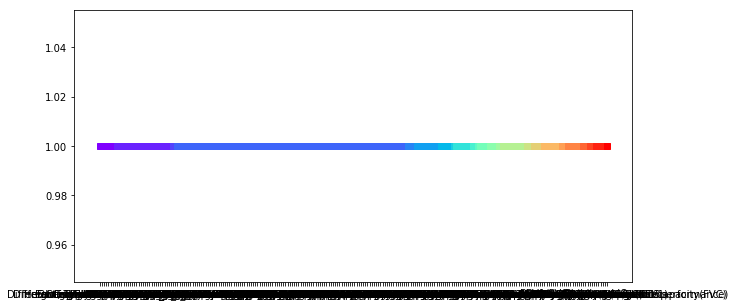

In [15]:
f=plt.figure(figsize=(10,5))
colors = iter(cm.rainbow(np.linspace(0, 1, len(eur["Category"].unique()))))
for x in eur["Category"].unique():
    plt.errorbar(eur[eur["Category"]==x]["trait2"],1,fmt="o",label=x,marker='s',color=next(colors))
plt.savefig("../plots/eur.ldhub.legend.pdf")

### Compare LDhub results

/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # Remove the CWD from sys.path while we load stuff.
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  # This is added back by InteractiveShellApp.init_path()
/cellar/users/mpagadal/Programs/miniconda3/envs/baseold/lib/python3.7/site-packages/ipykernel_launcher.py:12: SettingWithCopyW

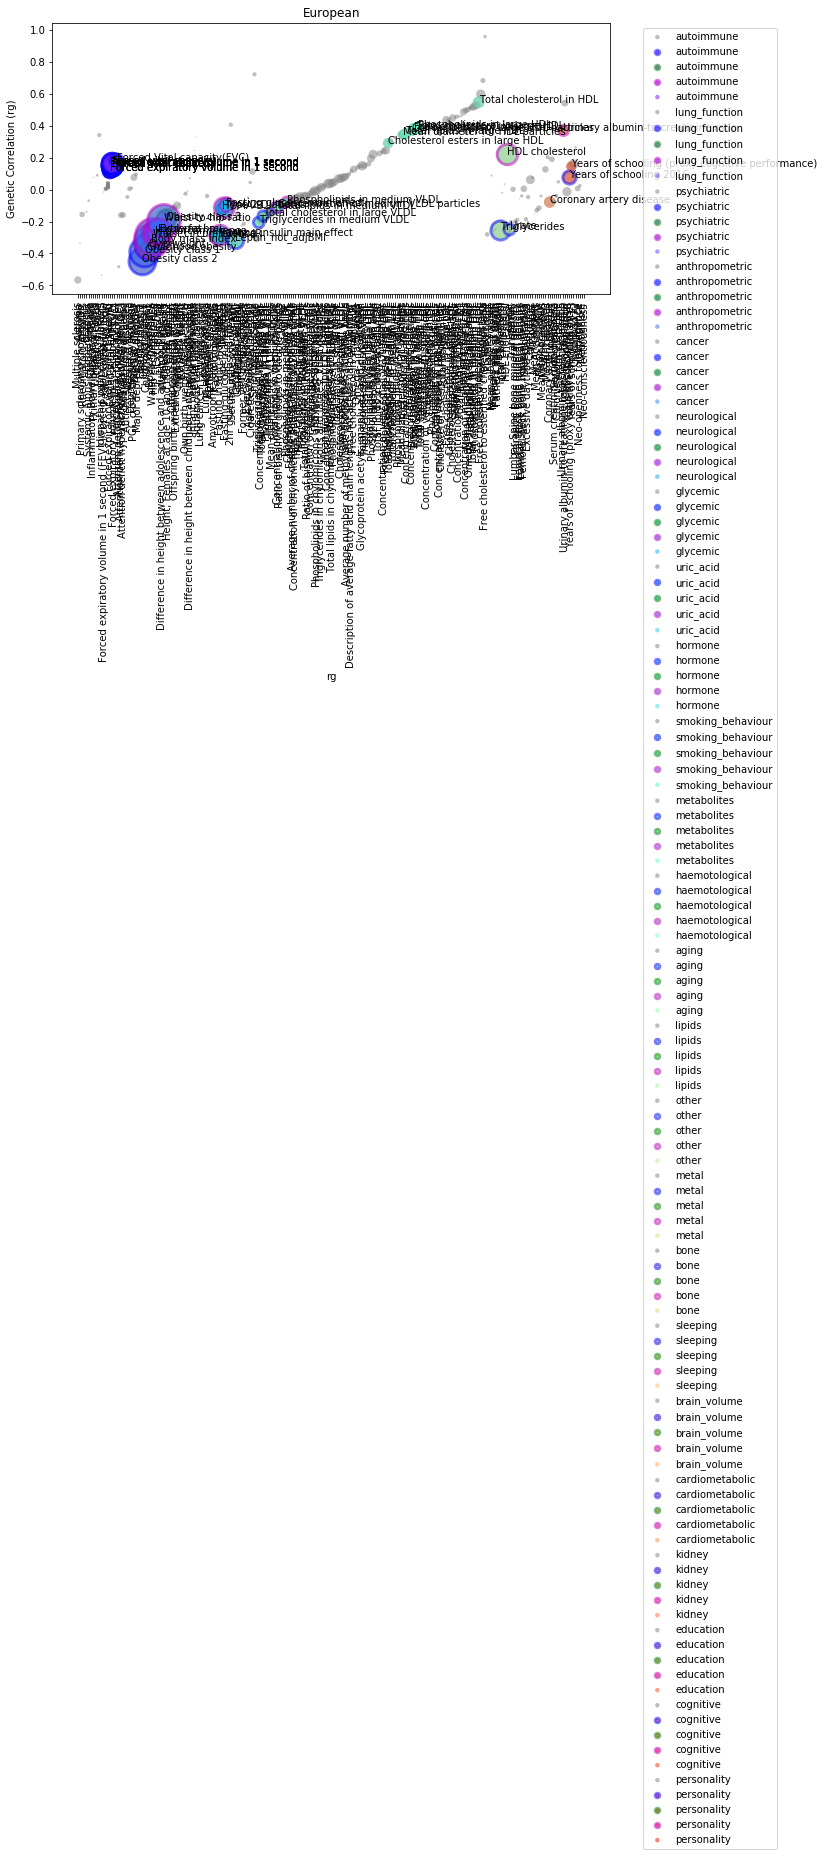

In [14]:
#get ldhub results
eur=pd.read_csv("../data/ldhub/ldhub.mvp.eur.txt.857adeaf-4a10-44ce-ba54-d7e04916e12f.rg.results.csv")
afr=pd.read_csv("../data/ldhub/ldhub.mvp.afr.txt.7c43e30f-cba2-4e37-8264-a037b85152fc.rg.results.csv")
his=pd.read_csv("../data/ldhub/ldhub.mvp.his.txt.c1342923-96f4-403d-ae31-04b7a87db00c.rg.results.csv")

eur=fdr(eur[~eur["p"].isnull()],"p") #fdr
eur=eur[eur["Category"]!="ukbb"]
eur=eur[eur["Category"]!="reproductive"]

#scale size
eur["size"]=eur["-log10(fdr)"]*50

#sort values by genetic correlation and remove duplicates
eur=eur.sort_values("rg",ascending=False).drop_duplicates("trait2").sort_index()

#merge results
ldhub=pd.merge(eur[["trait2","PMID","Category","ethnicity","rg","se","z","p","fdr","size"]],afr[["trait2","PMID","Category","ethnicity","rg","se","z","p"]],on=["trait2","PMID","Category","ethnicity"],how="left",suffixes=("_eur","_afr"))
ldhub=pd.merge(ldhub,his[["trait2","rg","se","z","p","PMID","Category","ethnicity"]],on=["trait2","PMID","Category","ethnicity"],how="left")

ldhub["rg_upper"]=ldhub["rg_eur"]+(2*ldhub["se_eur"])
ldhub["rg_lower"]=ldhub["rg_eur"]-(2*ldhub["se_eur"])

ldhub["afr_diff"]=np.where((ldhub["rg_afr"]>ldhub["rg_upper"])|(ldhub["rg_afr"]<ldhub["rg_lower"]),1,0)
ldhub["his_diff"]=np.where((ldhub["rg"]>ldhub["rg_upper"])|(ldhub["rg"]<ldhub["rg_lower"]),1,0)

ldhub["compare"]=np.where((ldhub["afr_diff"]==1)&(ldhub["his_diff"]==1),"both","shared")
ldhub["compare"]=np.where((ldhub["afr_diff"]==1)&(ldhub["his_diff"]==0),"african",ldhub["compare"])
ldhub["compare"]=np.where((ldhub["afr_diff"]==0)&(ldhub["his_diff"]==1),"hispanic",ldhub["compare"])

mp_outline={"shared":"none","hispanic":"g","african":"b","both":"m"}

f=plt.figure(figsize=(10,5))
ldhub=ldhub.sort_values(by="rg")

colors = iter(cm.rainbow(np.linspace(0, 1, len(ldhub["Category"].unique()))))

for x in ldhub["Category"].unique():
    #plot nonsignificant results
    plt.scatter(ldhub[ldhub["Category"]==x]["trait2"],ldhub[ldhub["Category"]==x]["rg"],s=ldhub[ldhub["Category"]==x]["size"],label=x,color="gray",alpha=0.5, edgecolors='none')
    c=next(colors)
    #plot significant results
    ldhub_sig=ldhub[ldhub["fdr"]<.01]
    
    for cat in ldhub_sig["compare"].unique():
        ldhub_cat=ldhub_sig[ldhub_sig["compare"]==cat]
        plt.scatter(ldhub_cat[ldhub_cat["Category"]==x]["trait2"],ldhub_cat[ldhub_cat["Category"]==x]["rg"],s=ldhub_cat[ldhub_cat["Category"]==x]["size"],label=x,alpha=0.5, color=c, edgecolors=mp_outline[cat],linewidths=3)
    
    for i,row in ldhub_sig[ldhub_sig["Category"]==x].iterrows():
        plt.text(row["trait2"],float(row["rg"]),row["trait2"],color="black")

plt.xlabel("rg")
plt.xticks(rotation=90)
plt.ylabel("Genetic Correlation (rg)")
plt.title("European")

#make legend plot points same size
lgnd = plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',  fontsize=10)
for handle in lgnd.legendHandles:
    handle.set_sizes([20.0])
plt.savefig("../plots/ldhub/ldhub.pdf")

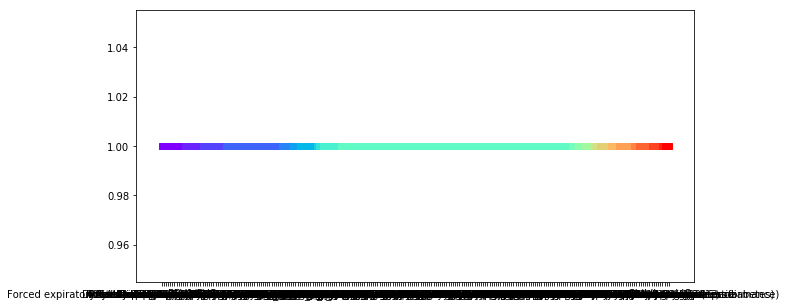

In [20]:
f=plt.figure(figsize=(10,5))
colors = iter(cm.rainbow(np.linspace(0, 1, len(eur["Category"].unique()))))
for x in ldhub["Category"].unique():
    plt.errorbar(ldhub[ldhub["Category"]==x]["trait2"],1,fmt="o",label=x,marker='s',color=next(colors))
plt.savefig("../plots/ldhub/ldhub.legend.pdf")

### Get correlation

In [21]:
compare_corr=ldhub[ldhub["fdr"]<.1]
compare_corr=compare_corr.reset_index()
compare_corr=compare_corr.sort_values(by="Category")
category_corr=compare_corr[["Category","rg_eur","rg_afr","rg"]].groupby("Category").mean()

<Figure size 720x720 with 0 Axes>

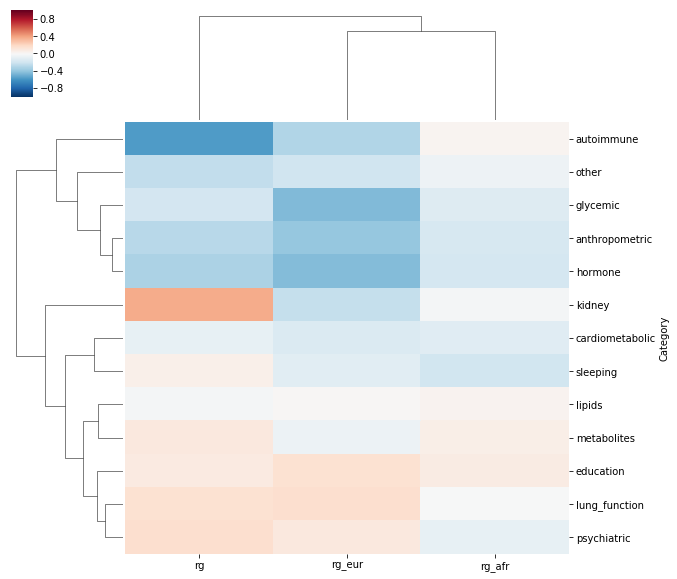

In [22]:
fig = plt.figure(figsize=(10,10))
sns.clustermap(category_corr,cmap="RdBu_r",vmin=-1,vmax=1)
plt.savefig("../plots/ldhub/category.corr.pdf")

In [34]:
trait_corr=compare_corr[["trait2","rg_eur","rg_afr","rg"]].groupby("trait2").mean()

<Figure size 1080x720 with 0 Axes>

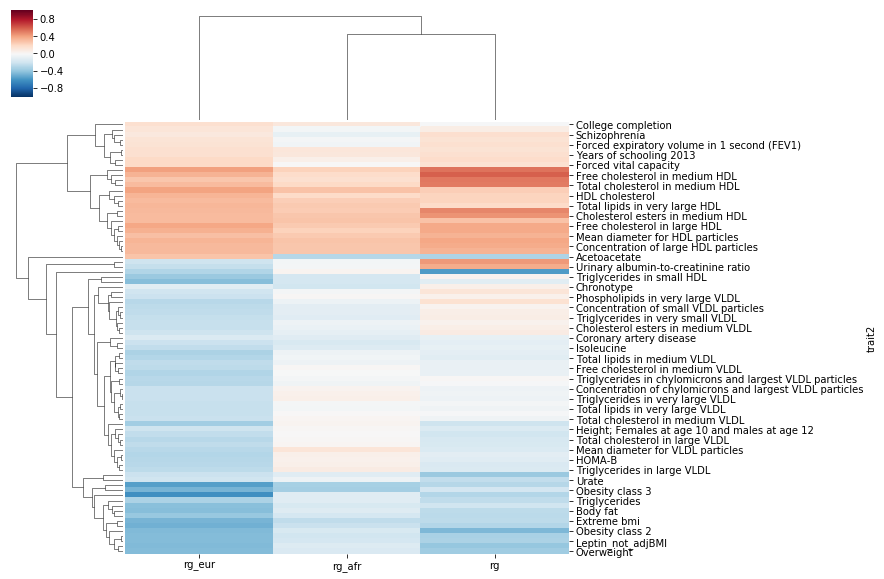

In [36]:
fig = plt.figure(figsize=(15,10))
ax=sns.clustermap(trait_corr,cmap="RdBu_r",vmin=-1,vmax=1)
plt.savefig("../plots/ldhub/trait.corr.pdf")